In [6]:
from pymatgen.core import Structure, Lattice
# Create the NaCl structure
lattice = Lattice.cubic(5.64)  # Lattice parameter for NaCl
structure = Structure(lattice, ["Na", "Cl"], [[0, 0, 0], [0.5, 0.5, 0.5]])

structure.sort()  # this groups all elements of a single type together, makes the POTCAR easier

print(structure)

Full Formula (Na1 Cl1)
Reduced Formula: NaCl
abc   :   5.640000   5.640000   5.640000
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (2)
  #  SP      a    b    c
---  ----  ---  ---  ---
  0  Na    0    0    0
  1  Cl    0.5  0.5  0.5


In [4]:

# define a helper function for printing the contents of files
def print_file(fname, nlines=10, header=False):
    with open(fname) as f:
        lines = f.readlines()
        if nlines == 0:
            nlines = len(lines)
        content = "".join(lines[:nlines])
        if len(lines) > nlines:
            content += "..."
        if header:
            print(f"---{fname}---")
        print(content)

In [7]:
# Create and write the INCAR file

from pymatgen.io.vasp import Incar

incar = Incar({
    "ENCUT": 520,
    "IBRION": 2,
    "ISIF": 3,
    "ISMEAR": -5,
    "SIGMA": 0.1,
    "EDIFF": 1e-5,
    "LMAXMIX": 4,
    "NSW": 50
})

incar.write_file("INCAR")

print_file("INCAR", nlines=10)

EDIFF = 1e-05
ENCUT = 520.0
IBRION = 2
ISIF = 3
ISMEAR = -5
LMAXMIX = 4
NSW = 50
SIGMA = 0.1



In [8]:
# Create and write the POSCAR file

from pymatgen.io.vasp import Poscar

poscar = Poscar(structure)
poscar.write_file("POSCAR")

print_file("POSCAR")

Na1 Cl1
1.0
   5.6399999999999997    0.0000000000000000    0.0000000000000000
   0.0000000000000000    5.6399999999999997    0.0000000000000000
   0.0000000000000000    0.0000000000000000    5.6399999999999997
Na Cl
1 1
direct
   0.0000000000000000    0.0000000000000000    0.0000000000000000 Na
   0.5000000000000000    0.5000000000000000    0.5000000000000000 Cl



In [9]:
# Create and write the KPOINTS file

from pymatgen.io.vasp import Kpoints

kpoints = Kpoints.automatic(1000)
kpoints.write_file("KPOINTS")

print_file("KPOINTS")

Fully automatic kpoint scheme
0
Automatic
1000



C:\Users\Think\AppData\Local\Temp\ipykernel_35120\2268845173.py:5: DeprecationWarning: Please use INCAR KSPACING tag.
  kpoints = Kpoints.automatic(1000)


pmg config --add PMG_VASP_PSP_DIR <MY_PSP>

In [ ]:
# Create and write the POTCAR file

from pymatgen.io.vasp import Potcar

# Specify the POTCAR symbols for NaCl --> these should be in the same order as POSCAR
symbols = ["Na_pv", "Cl"]

potcar = Potcar(symbols, functional="PBE")  # remember that your functional should match your installed POTCARs
potcar.write_file("POTCAR")

print_file("POTCAR", nlines=0)

In [10]:
from pymatgen.io.vasp.sets import MPRelaxSet

# Generate VASP input files using MPRelaxSet
vasp_input_set = MPRelaxSet(structure)
vasp_input_set.write_input(".")

# Print the outputs
print_file("INCAR", nlines=10, header=True)
print_file("KPOINTS", nlines=10, header=True)
print_file("POSCAR", nlines=10, header=True)
print_file("POTCAR", nlines=10, header=True)

---INCAR---
ALGO = Fast
EDIFF = 0.0001
ENCUT = 520.0
IBRION = 2
ISIF = 3
ISMEAR = -5
ISPIN = 2
LASPH = True
LORBIT = 11
LREAL = Auto
...
---KPOINTS---
pymatgen with grid density = 177 / number of atoms
0
Monkhorst
4 4 4

---POSCAR---
Na1 Cl1
1.0
   5.6399999999999997    0.0000000000000000    0.0000000000000000
   0.0000000000000000    5.6399999999999997    0.0000000000000000
   0.0000000000000000    0.0000000000000000    5.6399999999999997
Na Cl
1 1
direct
   0.0000000000000000    0.0000000000000000    0.0000000000000000 Na
   0.5000000000000000    0.5000000000000000    0.5000000000000000 Cl

---POTCAR---
  PAW_PBE Na_pv 19Sep2006                
   7.00000000000000     
 parameters from PSCTR are:
   VRHFIN =Na: p6s1
   LEXCH  = PE
   EATOM  =   766.0439 eV,   56.3026 Ry

   TITEL  = PAW_PBE Na_pv 19Sep2006
   LULTRA =        F    use ultrasoft PP ?
   IUNSCR =        1    unscreen: 0-lin 1-nonlin 2-no
...


c:\Users\Think\anaconda3\lib\site-packages\pymatgen\io\vasp\sets.py:486: BadInputSetWarning: POTCAR data with symbol Na_pv is not known by pymatgen to correspond with the selected user_potcar_functional='PBE'. This POTCAR is known to correspond with functionals ['PBE_52', 'PBE_54']. Please verify that you are using the right POTCARs!
  potcar="\n".join(self.potcar_symbols) if potcar_spec else self.potcar,
c:\Users\Think\anaconda3\lib\site-packages\pymatgen\io\vasp\sets.py:486: BadInputSetWarning: POTCAR data with symbol Cl is not known by pymatgen to correspond with the selected user_potcar_functional='PBE'. This POTCAR is known to correspond with functionals ['PBE_52', 'PBE_54']. Please verify that you are using the right POTCARs!
  potcar="\n".join(self.potcar_symbols) if potcar_spec else self.potcar,


In [11]:
from pymatgen.io.vasp.sets import MPStaticSet

vasp_input_set = MPStaticSet(structure)
vasp_input_set.write_input(".")

print_file("INCAR", nlines=0, header=True)
print_file("KPOINTS", nlines=10, header=True)

---INCAR---
ALGO = Fast
EDIFF = 0.0001
ENCUT = 520.0
ISMEAR = -5
ISPIN = 2
LASPH = True
LCHARG = True
LORBIT = 11
LREAL = False
LWAVE = False
MAGMOM = 2*0.6
NELM = 100
NSW = 0
PREC = Accurate
SIGMA = 0.05

---KPOINTS---
pymatgen with grid density = 277 / number of atoms
0
Gamma
5 5 5



In [12]:
# Define custom settings
user_incar_settings = {"ENCUT": 700}
user_kpoint_settings = {"reciprocal_density": 1000}  # kpoints per inverse Angstrom in reciprocal space

# Generate VASP input files using MPStaticSet with custom settings
vasp_input_set = MPStaticSet(
    structure, 
    user_incar_settings=user_incar_settings,
    user_kpoints_settings=user_kpoint_settings
)
vasp_input_set.write_input(".")

print_file("INCAR", nlines=10, header=True)
print_file("KPOINTS", nlines=10, header=True)

---INCAR---
ALGO = Fast
EDIFF = 0.0001
ENCUT = 700.0
ISMEAR = -5
ISPIN = 2
LASPH = True
LCHARG = True
LORBIT = 11
LREAL = False
LWAVE = False
...
---KPOINTS---
pymatgen with grid density = 2765 / number of atoms
0
Gamma
11 11 11



In [13]:
# CONTCAR example

s = Structure.from_file("files/Si_relax_output/CONTCAR")  # The CONTCAR does not have its own dedicated object
print(s)

Full Formula (Si2)
Reduced Formula: Si
abc   :   3.867871   3.867872   3.867870
angles:  60.000012  60.000003  60.000011
pbc   :       True       True       True
Sites (2)
  #  SP        a      b      c
---  ----  -----  -----  -----
  0  Si    0.875  0.875  0.875
  1  Si    0.125  0.125  0.125


In [14]:
# OSZICAR example

from pymatgen.io.vasp.outputs import Oszicar

oszicar = Oszicar("files/Si_relax_output/OSZICAR")

# Display the number of ionic steps
num_ionic_steps = len(oszicar.ionic_steps)
print(f"Number of ionic steps: {num_ionic_steps}")

# Access and display the final ionic step
final_step = oszicar.ionic_steps[-1]
print(f"Final ionic step: {final_step}")

# Display the energy and free energy of the final step
final_energy = final_step["E0"]
print(f"Final energy: {final_energy} eV")

print("")
print("All ionic and electronic steps:")
for istep_num, ionic_step in enumerate(oszicar.ionic_steps):
    print(istep_num, ionic_step)
    for estep_num, electronic_step in enumerate(oszicar.electronic_steps[istep_num]):
        print("--->", estep_num, electronic_step)

Number of ionic steps: 1
Final ionic step: {'F': -10.841457, 'E0': -10.841457, 'dE': -10.8415, 'mag': -0.0}
Final energy: -10.841457 eV

All ionic and electronic steps:
0 {'F': -10.841457, 'E0': -10.841457, 'dE': -10.8415, 'mag': -0.0}
---> 0 {'N': 1, 'E': -1.33097315926, 'dE': -1.331, 'deps': -331.09, 'ncg': 1280, 'rms': 40.3}
---> 1 {'N': 2, 'E': -10.9517951747, 'dE': -9.6208, 'deps': -9.6036, 'ncg': 1888, 'rms': 3.72}
---> 2 {'N': 3, 'E': -11.0107039148, 'dE': -0.058909, 'deps': -0.058909, 'ncg': 1440, 'rms': 0.368}
---> 3 {'N': 4, 'E': -11.0108565494, 'dE': -0.00015263, 'deps': -0.00015263, 'ncg': 2384, 'rms': 0.0201}
---> 4 {'N': 5, 'E': -11.0108565559, 'dE': -6.5514e-09, 'deps': -6.5514e-09, 'ncg': 1456, 'rms': 0.000122, 'rms(c)': 0.475}
---> 5 {'N': 6, 'E': -10.8940848399, 'dE': 0.11677, 'deps': -0.0025517, 'ncg': 1280, 'rms': 0.056, 'rms(c)': 0.29}
---> 6 {'N': 7, 'E': -10.8399729817, 'dE': 0.054112, 'deps': -0.0060522, 'ncg': 1280, 'rms': 0.0939, 'rms(c)': 0.018}
---> 7 {'N': 

In [15]:
# OUTCAR example

from pymatgen.io.vasp.outputs import Outcar

# Initialize the OUTCAR object
outcar = Outcar("files/Si_optics/OUTCAR")

print(f"Final energy: {outcar.final_energy}")
print(f"Run statistics: {outcar.run_stats}")

Final energy: -10.84724352
Run statistics: {'Average memory used (kb)': None, 'Maximum memory used (kb)': 43950080.0, 'Elapsed time (sec)': 10.288, 'System time (sec)': 1.297, 'User time (sec)': 8.89, 'Total CPU time used (sec)': 10.187, 'cores': 4}


In [16]:
import pandas as pd

# For some OUTCAR properties, you need to explicitly call a read() function
# This is to save time in the initial parse of an OUTCAR
outcar.read_freq_dielectric()

dielectric_tensor = outcar.dielectric_tensor_function

data = {
    "Energy (eV)": outcar.dielectric_energies,
    "Dielectric Tensor (xx)": [tensor[0][0] for tensor in dielectric_tensor],
    "Dielectric Tensor (yy)": [tensor[1][1] for tensor in dielectric_tensor],
    "Dielectric Tensor (zz)": [tensor[2][2] for tensor in dielectric_tensor],
    "Dielectric Tensor (xy)": [tensor[0][1] for tensor in dielectric_tensor],
    "Dielectric Tensor (xz)": [tensor[0][2] for tensor in dielectric_tensor],
    "Dielectric Tensor (yz)": [tensor[1][2] for tensor in dielectric_tensor]
}

df = pd.DataFrame(data)
print(df.head())

   Energy (eV)  Dielectric Tensor (xx)  Dielectric Tensor (yy)  \
0     0.000000    13.606245+ 0.000000j    13.606250+ 0.000000j   
1     0.007019    13.606285+ 0.001170j    13.606291+ 0.001170j   
2     0.014039    13.606408+ 0.002339j    13.606414+ 0.002339j   
3     0.021058    13.606613+ 0.003509j    13.606618+ 0.003509j   
4     0.028077    13.606899+ 0.004679j    13.606905+ 0.004679j   

   Dielectric Tensor (zz)  Dielectric Tensor (xy)  Dielectric Tensor (xz)  \
0    13.606249+ 0.000000j     -0.000001+0.000000j     -0.000002+0.000000j   
1    13.606290+ 0.001170j     -0.000001+0.000000j     -0.000002+0.000000j   
2    13.606413+ 0.002339j     -0.000001+0.000000j     -0.000002+0.000000j   
3    13.606617+ 0.003509j     -0.000001+0.000000j     -0.000002+0.000000j   
4    13.606904+ 0.004679j     -0.000001+0.000000j     -0.000002+0.000000j   

   Dielectric Tensor (yz)  
0     -0.000001+0.000000j  
1     -0.000001+0.000000j  
2     -0.000001+0.000000j  
3     -0.000001+0.000000j  


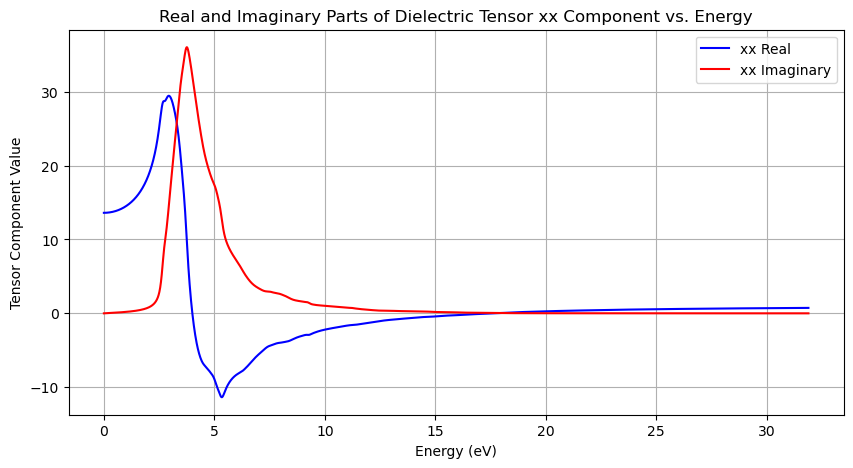

In [17]:
# Plot the dielectric function
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Real part of the xx component
plt.plot(data["Energy (eV)"], [x.real for x in data["Dielectric Tensor (xx)"]], label='xx Real', color='blue')

# Imaginary part of the xx component
plt.plot(data["Energy (eV)"], [x.imag for x in data["Dielectric Tensor (xx)"]], label='xx Imaginary', color='red')

plt.title('Real and Imaginary Parts of Dielectric Tensor xx Component vs. Energy')
plt.xlabel('Energy (eV)')
plt.ylabel('Tensor Component Value')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
# vasprun.xml example

from pymatgen.io.vasp.outputs import Vasprun

vasprun = Vasprun("files/Si_HSE_relax_output/vasprun.xml")

# Basic analysis
final_energy = vasprun.final_energy  # Final total energy
final_structure = vasprun.final_structure  # Final total energy

print(f"Final energy: {final_energy}")
print(f"Final structure: {final_structure}")

Final energy: -12.5326576 eV
Final structure: Full Formula (Si2)
Reduced Formula: Si
abc   :   3.844470   3.844470   3.844470
angles:  60.000006  60.000002  60.000010
pbc   :       True       True       True
Sites (2)
  #  SP        a      b      c
---  ----  -----  -----  -----
  0  Si     0.25   0.25   0.25
  1  Si    -0     -0     -0


c:\Users\Think\anaconda3\lib\site-packages\pymatgen\io\vasp\outputs.py:1328: UserWarning: No POTCAR file with matching TITEL fields was found in

  if potcar := self.get_potcars(path):
c:\Users\Think\anaconda3\lib\site-packages\pymatgen\io\vasp\outputs.py:1339: UserWarning: No POTCAR file with matching TITEL fields was found in

  potcar = self.get_potcars(path)


Band gap: {'direct': False, 'transition': '\\Gamma-(0.413,0.000,0.413)', 'energy': 1.1960000000000006}
Direct band gap: 3.331800000000001


C:\Users\Think\AppData\Local\Temp\ipykernel_35120\2139426429.py:20: UserWarning: Cannot get element projected data; either the projection data doesn't exist, or you don't have a compound with exactly 2 or 3 or 4 unique elements.
  ax_bs, ax_dos = bsp.get_plot(bs, dos)


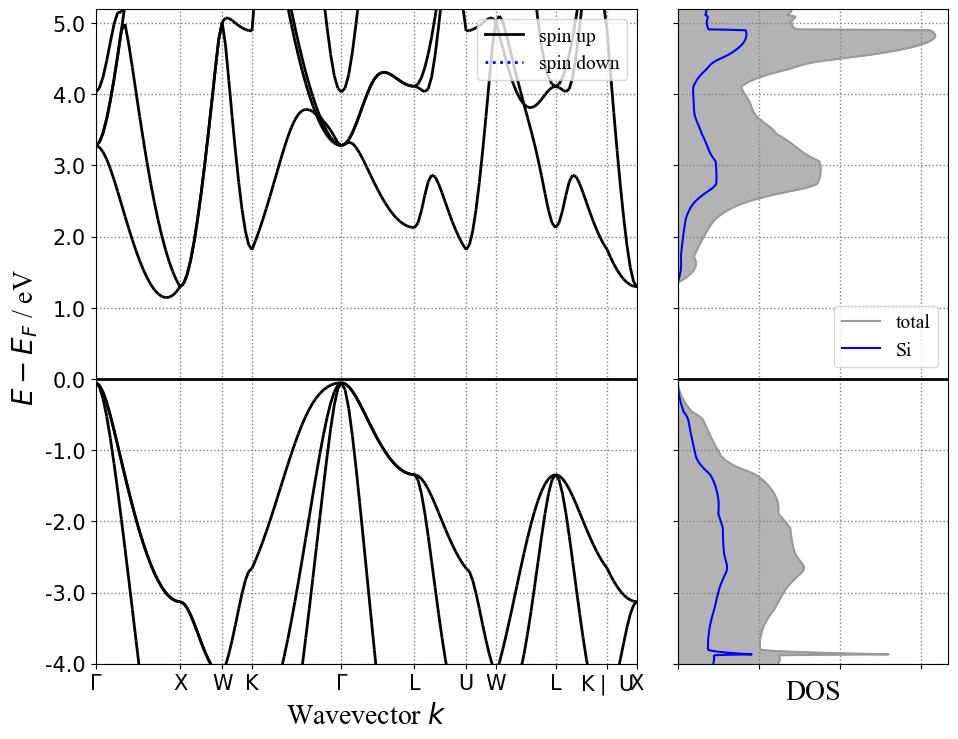

In [19]:
# Get the DOS and band structure from vasprun.xml
import matplotlib.pyplot as plt
from pymatgen.io.vasp.outputs import Vasprun
from pymatgen.electronic_structure.plotter import BSDOSPlotter

# Parse the band structure
bs = Vasprun("files/Si_HSE_band_structure_line/vasprun.xml").get_band_structure(line_mode=True)

# Inspect the band structure for the band gap
band_gap = bs.get_band_gap()
band_gap_direct = bs.get_direct_band_gap()
print(f"Band gap: {band_gap}")
print(f"Direct band gap: {band_gap_direct}")

# Parse the DOS
dos = Vasprun("files/Si_HSE_band_structure_uniform/vasprun.xml").complete_dos

# Plot the band structure and DOS
bsp = BSDOSPlotter()
ax_bs, ax_dos = bsp.get_plot(bs, dos)
plt.show()